In [25]:
import os
import pandas as pd
import joblib

# Thiết lập đường dẫn tới thư mục artifacts (nơi chứa file pkl và csv)
# Nếu file .ipynb nằm cùng thư mục với file script cũ, BASE_DIR sẽ là thư mục cha.
# Bạn có thể điều chỉnh lại đường dẫn cho đúng với cấu trúc thư mục của mình.
BASE_DIR = os.path.dirname(os.getcwd()) # Lấy thư mục cha của thư mục hiện tại
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts')

print(f"📂 Thư mục chứa artifacts: {ARTIFACTS_DIR}")

📂 Thư mục chứa artifacts: h:\Project-ADY\Project_ADY201m_GR01_AI2009_H1\artifacts


In [26]:
# 1. Load các tập dữ liệu Train/Test đã chia sẵn
X_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_train_tree.csv'))
X_test = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_test_tree.csv'))
y_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_train_tree.csv'))
y_test = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_test_tree.csv'))

# 2. Load Pipeline tiền xử lý (chỉ chứa bước One-Hot Encoder)
preprocessing_pipeline = joblib.load(os.path.join(ARTIFACTS_DIR, 'tree_preprocessing_pipeline.pkl'))

print("✅ Đã load thành công dữ liệu và pipeline vào Notebook!")
print(f"Kích thước tập X_train gốc: {X_train.shape}")

✅ Đã load thành công dữ liệu và pipeline vào Notebook!
Kích thước tập X_train gốc: (5634, 18)


In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train.values.ravel())

print("✅ Random Forest training completed!")

✅ Random Forest training completed!


In [28]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

pd.DataFrame([metrics])

,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,0.788502,0.629252,0.494652,0.553892,0.832044


In [30]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df["Importance (%)"] = (
    importance_df["Importance"] * 100
).round(2)

importance_df.head(20)

,Feature,Importance,Importance (%)
10,remainder__TotalCharges,0.157668,15.77
9,remainder__MonthlyCharges,0.149466,14.95
16,remainder__monthly_charges_ratio,0.148611,14.86
6,remainder__Tenure,0.131672,13.17
7,remainder__Contract,0.089310,8.93
3,encoder__tenure_group,0.042166,4.22
1,encoder__PaymentMethod,0.040946,4.09
0,encoder__Dependents,0.040293,4.03
15,remainder__service_diversity,0.034312,3.43
2,encoder__InternetService,0.030128,3.01


In [31]:
rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred)],
    "Recall": [recall_score(y_test, y_pred)],
    "F1-score": [f1_score(y_test, y_pred)],
    "ROC-AUC": [roc_auc_score(y_test, y_prob)]
})

rf_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.788502,0.629252,0.494652,0.553892,0.832044


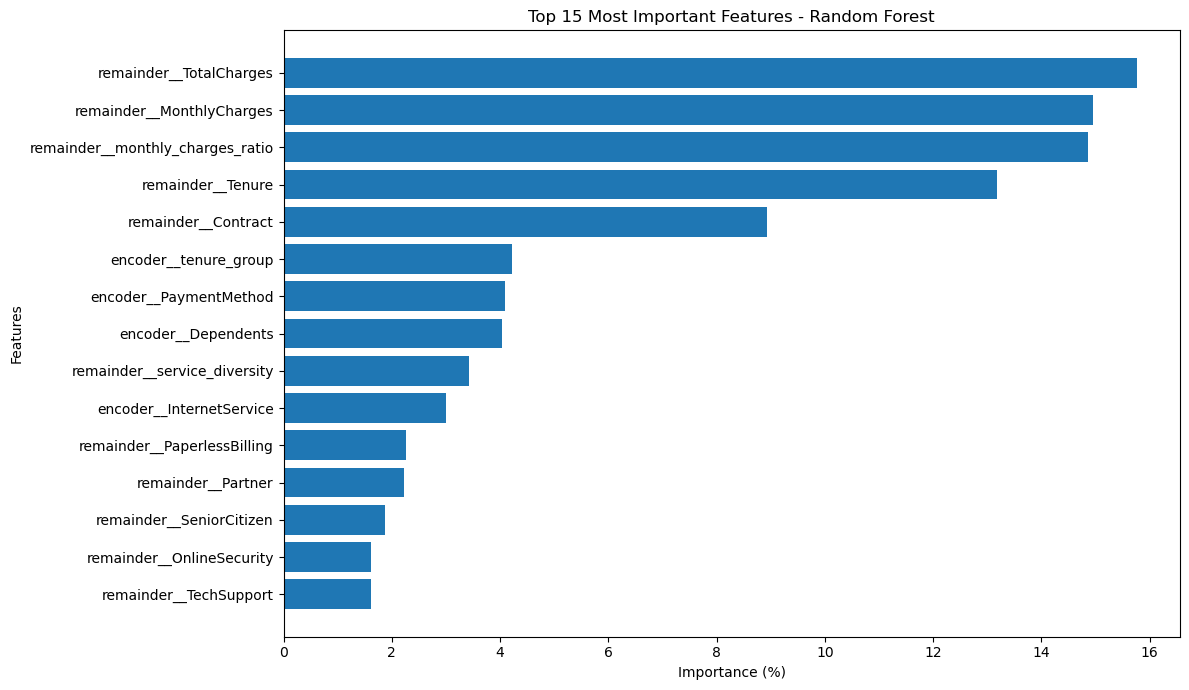


BUSINESS INSIGHTS

1. Contract and Tenure are among the most important predictors.
   Customers with shorter contracts and lower tenure are more likely to churn.

2. MonthlyCharges, TotalCharges, and monthly_charges_ratio
   have the highest importance scores.
   High-cost customers should be monitored through an early-warning system.

3. Engineered features such as tenure_group,
   service_diversity, and monthly_charges_ratio
   contribute significantly to churn prediction,
   demonstrating the effectiveness of feature engineering.



In [32]:
import matplotlib.pyplot as plt

top15 = importance_df.head(15)

plt.figure(figsize=(12,7))

plt.barh(
    top15["Feature"],
    top15["Importance (%)"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance (%)")
plt.ylabel("Features")
plt.title("Top 15 Most Important Features - Random Forest")

plt.tight_layout()
plt.show()
print("""
BUSINESS INSIGHTS

1. Contract and Tenure are among the most important predictors.
   Customers with shorter contracts and lower tenure are more likely to churn.

2. MonthlyCharges, TotalCharges, and monthly_charges_ratio
   have the highest importance scores.
   High-cost customers should be monitored through an early-warning system.

3. Engineered features such as tenure_group,
   service_diversity, and monthly_charges_ratio
   contribute significantly to churn prediction,
   demonstrating the effectiveness of feature engineering.
""")